# Bottom-Left法を実装する

In [1]:
from pathlib import Path 

class Env:

    def __init__(self, input_txt_path: Path):
        self.W, self.D, self.N, self.a = self._input(input_txt_path)

    def _input(self, txt_path):
        with open(txt_path, mode="r") as file:
            lines = file.readlines()
        W, D, N = map(int, lines[0].split())
        a = []
        for line, d in zip(lines[1:], range(D)):
            d = list(map(int, line.split()))
            a.append(d)
        return W, D, N, a

In [2]:
sample_txt_path = Path("tools/in/0001.txt")
env = Env(sample_txt_path)

In [3]:
import random
import math

class Rectangle:
    def __init__(self, area, width, height, min_len, max_len, x=0, y=0):
        self.area = area
        self.width = width
        self.height = height
        self.min_len = min_len
        self.max_len = max_len
        self.x = x
        self.y = y

    def random_resize(self):
        change_len = max(0, int(self.area ** 0.5 * 0.2))
        if random.random() < 0.5:
            next_w = random.randint(max(self.min_len, self.width - change_len), min(self.max_len, self.width + change_len))
            next_h = math.ceil(self.area / next_w)
        else:
            next_h = random.randint(max(self.min_len, self.height - change_len), min(self.max_len, self.height + change_len))
            next_w = math.ceil(self.area / next_h)            
        self.width = next_w
        self.height = next_h

    def __str__(self):
        return f"Rectangle({self.width}, {self.height})"

In [4]:
def bl_candidates(x,y,w,h):
    cand=[(0,0)]
    for j in range(len(x)):
        for k in range(j):
            cand += [(x[j]+ w[j],y[k]+h[k])]
            cand += [(x[k]+ w[k],y[j]+h[j])]
    for j in range(len(x)):
        cand += [(0,y[j]+h[j])]
        cand += [(x[j]+w[j] ,0)]
    return cand

def is_feas(p,x,y,w,h,W,H,now_w,now_h):
    if p[0] < 0 or W < p[0]+now_w:
        return False
    if p[1] < 0 or H < p[1]+now_h:
        return False
    for j in range(len(x)):
        if max(p[0],x[j]) < min(p[0]+now_w,x[j]+w[j]):
            if max(p[1],y[j]) < min(p[1]+now_h,y[j]+h[j]):
                return False
    return True

def BL_method(rectangles:list[Rectangle],W,H):
    w = [rectangle.width for rectangle in rectangles]
    h = [rectangle.height for rectangle in rectangles]
    placed_x,placed_y=[],[]
    placed_w,placed_h=[],[]

    not_placed_ind = []
    not_place_area = 0
    for i in range(len(w)):
        now_w, now_h = w[i], h[i]
        blfp=[]
        cand = bl_candidates(placed_x,placed_y,placed_w,placed_h)
        for p in cand:
            if is_feas(p,placed_x,placed_y,placed_w,placed_h,W,H,now_w,now_h):
                blfp += [p]
        if len(blfp) == 0:
            not_placed_ind += [i]
            not_place_area += now_w*now_h
            continue
        min_p = min(blfp ,key=lambda v:(v[1],v[0]))
        placed_x += [min_p[0]]
        placed_y += [min_p[1]]
        placed_w += [now_w]
        placed_h += [now_h]
    return placed_x,placed_y,placed_w,placed_h,not_place_area

In [5]:
import math
import random

rectangles: list[Rectangle] = []
for area in env.a[0]:
    divs = []
    for div1 in range(1, 1000 + 1):
        div2 = math.ceil(area / div1)
        if 1 <= div1 <= 1000 and 1 <= div2 <= 1000:
            divs.append(div1)
            divs.append(div2)
    min_len = min(divs)
    max_len = max(divs)
    if random.random() < 0.5:
        w = random.randint(min_len, max_len)
        h = math.ceil(area / w)
    else:
        h = random.randint(min_len, max_len)
        w = math.ceil(area / h)
    rectangles.append(Rectangle(
        area=area,
        width=w,
        height=h,
        min_len=min_len,
        max_len=max_len
    ))
rectangles = sorted(rectangles, key=lambda x: x.height, reverse=True)

In [6]:
from copy import deepcopy
W=1000
INF = 10**18
N = len(rectangles)
best_rectangles = deepcopy(rectangles)

best_x, best_y, best_w, best_h = [], [], [], []
best_cost = INF
for simulate_n in range(100000):

    # 適当な近傍探索
    
    now_rectangles = deepcopy(best_rectangles)
    if random.random() < 1/3:
        i = random.randint(0, N-1)
        shift = random.randint(1, max(1, round(N * 0.2)))
        j = random.randint(max(0, i-shift), min(N-1, i+shift))

        now_rectangles[i], now_rectangles[j] = now_rectangles[j], now_rectangles[i]
    elif random.random() < 1/3:
        i = random.randint(0, N-1)
        now_rectangles[i].random_resize()
    else:
        i = random.randint(0, N-1)
        shift = random.randint(1, max(1, round(N * 0.2)))
        j = random.randint(max(0, i-shift), min(N-1, i+shift))
        now_rectangles[i], now_rectangles[j] = now_rectangles[j], now_rectangles[i]

        now_rectangles[i].random_resize()
        now_rectangles[j].random_resize()
    
    placed_x,placed_y,placed_w,placed_h,not_place_area=BL_method(now_rectangles,W,W)
    if not_place_area < best_cost:
        best_cost = not_place_area
        best_rectangles = deepcopy(now_rectangles)
        best_x = placed_x
        best_y = placed_y
        best_w = placed_w
        best_h = placed_h

    if simulate_n % 100 == 0:
        print(f"simulate_n {simulate_n}, now_cost: {not_place_area}, best_cost: {best_cost}")

simulate_n 0, now_cost: 134306, best_cost: 134306
simulate_n 100, now_cost: 97812, best_cost: 97812
simulate_n 200, now_cost: 158092, best_cost: 97790
simulate_n 300, now_cost: 97790, best_cost: 97790
simulate_n 400, now_cost: 92741, best_cost: 78245
simulate_n 500, now_cost: 93518, best_cost: 77832
simulate_n 600, now_cost: 91976, best_cost: 77480
simulate_n 700, now_cost: 91976, best_cost: 77480
simulate_n 800, now_cost: 77140, best_cost: 77140
simulate_n 900, now_cost: 75111, best_cost: 75111
simulate_n 1000, now_cost: 76958, best_cost: 72608
simulate_n 1100, now_cost: 97213, best_cost: 69582
simulate_n 1200, now_cost: 76450, best_cost: 69571
simulate_n 1300, now_cost: 147970, best_cost: 69568
simulate_n 1400, now_cost: 76447, best_cost: 69568
simulate_n 1500, now_cost: 69564, best_cost: 69564
simulate_n 1600, now_cost: 70864, best_cost: 67498
simulate_n 1700, now_cost: 67490, best_cost: 67490
simulate_n 1800, now_cost: 145056, best_cost: 63040
simulate_n 1900, now_cost: 113666, bes

KeyboardInterrupt: 

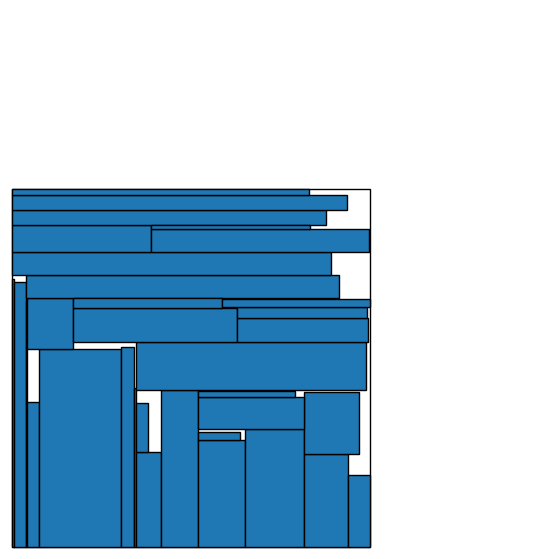

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig = plt.figure(figsize=(7, 7))
ax = plt.axes()

r = patches.Rectangle(xy=(0, 0), width=1000, height=1000, ec='#000000', fill=False)
ax.add_patch(r)

for x,y,w,h in zip(best_x, best_y, best_w, best_h):
    r = patches.Rectangle(xy=(x,y), width=w, height=h, ec='#000000', fill=True)
    ax.add_patch(r)

plt.xlim(-5, 1500)
plt.ylim(-5, 1500)
plt.axis('off')
ax.set_aspect('equal')